In [5]:
from sklearn import datasets
from sklearn import neighbors
from sklearn import model_selection as skms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = datasets.load_iris()
# 10 podatkovnih skupova velicine: 10% - 100%
# (5-fold CV)
train_sizes = np.linspace(.1, 1.0, 10)
nn = neighbors.KNeighborsClassifier()
(train_N, train_scores, test_scores) = skms.learning_curve(nn,
  iris.data, iris.target,
  cv=5, train_sizes=train_sizes)
# sažeti kroz 5 CV rezultata; jedan rezultat za svaku veličinu skupa podataka
df = pd.DataFrame(test_scores, index=(train_sizes*100).astype(int))
df['Mean 5-CV'] = df.mean(axis='columns')
df.index.name = "% Data Used"
display(df)

,0,1,2,3,4,Mean 5-CV
% Data Used,,,,,,
10,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
20,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
30,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
40,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
50,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
60,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
70,0.900000,0.800000,0.833333,0.866667,0.800000,0.840000
80,0.966667,0.933333,0.900000,0.900000,0.966667,0.933333
90,0.966667,1.000000,0.900000,0.966667,1.000000,0.966667


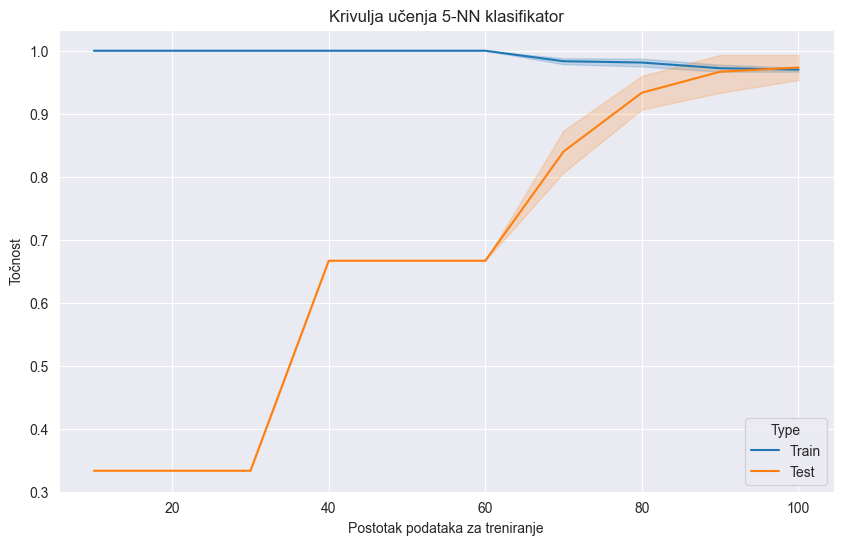

In [6]:
# kreiraj dataframe iz rezultata
train_df = pd.DataFrame(train_scores)
test_df = pd.DataFrame(test_scores)
# dodaj stupac za veličine skupova za treniranje
train_df['Data Used (%)'] = train_sizes * 100
test_df['Data Used (%)'] = train_sizes * 100
# dodaj stupac Train/Test
train_df['Type'] = 'Train'
test_df['Type'] = 'Test'
# Pretvori DataFrames u dugi format
train_melted = train_df.melt(id_vars=['Data Used (%)', 'Type'], var_name='Fold', value_name='Accuracy')
test_melted = test_df.melt(id_vars=['Data Used (%)', 'Type'], var_name='Fold', value_name='Accuracy')
# Spojite DataFrameove
combined_df = pd.concat([train_melted, test_melted])
# Crtanje sa lineplot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=combined_df, x='Data Used (%)', y='Accuracy', hue='Type')
ax.set_title("Krivulja učenja 5-NN klasifikator")
ax.set_xlabel("Postotak podataka za treniranje")
ax.set_ylabel("Točnost")
plt.grid(True)
plt.show()